# Entrainement sur Google colab

# Etape 0 -- Vérifier que le GPU est bien actif

In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Étape 1 — Upload de kaggle.json + config

In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


# Étape 2 — Installer la clé au bon endroit

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
print("Clé Kaggle installée ✅")

Clé Kaggle installée ✅


# Étape 3 — Télécharger le dataset

In [4]:
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:05<00:00, 16.9MB/s]



# Étape 4 — Décompresser

In [5]:
!unzip -q garbage-classification.zip -d /content/dataset
print("Décompression terminée ✅")

Décompression terminée ✅


# Étape 5 — Vérifier ce qu'on a

In [6]:
import os

dataset_path = '/content/dataset/Garbage classification/Garbage classification'

# Si ce chemin ne marche pas, on ajustera après avoir vu l'arborescence réelle
for classe in sorted(os.listdir(dataset_path)):
    n_images = len(os.listdir(os.path.join(dataset_path, classe)))
    print(f"{classe:15s} : {n_images} images")

cardboard       : 403 images
glass           : 501 images
metal           : 410 images
paper           : 594 images
plastic         : 482 images
trash           : 137 images


# Étape 6 — Imports et config

In [7]:
# ============================================================
# IMPORTS
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ============================================================
# CONFIGURATION GLOBALE
# ============================================================
DATASET_PATH = '/content/dataset/Garbage classification/Garbage classification'
IMG_SIZE = (224, 224)      # taille attendue par MobileNetV2
BATCH_SIZE = 32
SEED = 42                  # pour la reproductibilité

# Reproductibilité
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("Dataset:", DATASET_PATH)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dataset: /content/dataset/Garbage classification/Garbage classification


# Étape 7 — DataFrame des chemins et labels

Nombre total d'images: 2527

Répartition par classe:
label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64


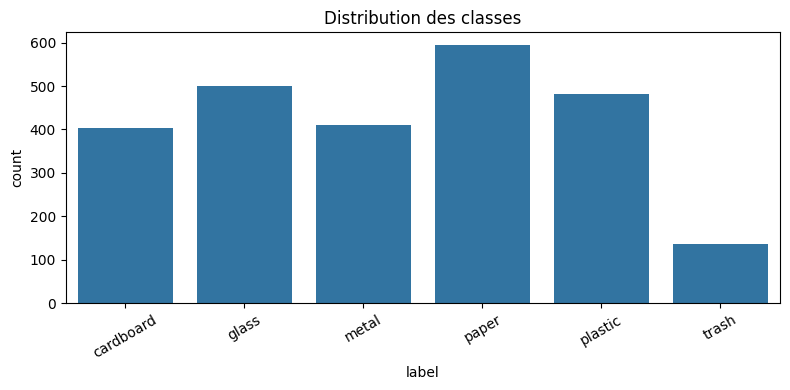

In [8]:
# On construit un DataFrame [path, label] pour toutes les images
data = []
for classe in sorted(os.listdir(DATASET_PATH)):
    class_dir = os.path.join(DATASET_PATH, classe)
    for image_name in os.listdir(class_dir):
        data.append({
            'path': os.path.join(class_dir, image_name),
            'label': classe
        })

df = pd.DataFrame(data)
print("Nombre total d'images:", len(df))
print("\nRépartition par classe:")
print(df['label'].value_counts())

# Visualisation de la distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='label', order=sorted(df['label'].unique()))
plt.title("Distribution des classes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Étape 8 — Split train / val / test 70/15/15 stratifié

In [9]:
# ============================================================
# SPLIT STRATIFIÉ EN 3 SETS : 70% train / 15% val / 15% test
# ============================================================

# 1er split : 70% train, 30% temp (val + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

# 2e split : couper temp en 50/50 → 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train : {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")

print("\n--- Répartition par classe ---")
comparison = pd.DataFrame({
    'train': train_df['label'].value_counts(),
    'val': val_df['label'].value_counts(),
    'test': test_df['label'].value_counts()
})
print(comparison)

Train : 1768 images (70.0%)
Val   : 379 images (15.0%)
Test  : 380 images (15.0%)

--- Répartition par classe ---
           train  val  test
label                      
cardboard    282   61    60
glass        350   75    76
metal        287   61    62
paper        416   89    89
plastic      337   72    73
trash         96   21    20


# Étape 9 — Data Generators avec augmentation

In [10]:
# ============================================================
# DATA GENERATORS
# ============================================================

# Generator pour le TRAIN : avec data augmentation + preprocess_input
# preprocess_input met les pixels dans la plage attendue par MobileNetV2 [-1, 1]
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Generator pour VAL et TEST : uniquement preprocess (pas d'augmentation)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Création des flows depuis les DataFrames
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Mapping classe → index
print("\nMapping classes → indices:")
print(train_gen.class_indices)

Found 1768 validated image filenames belonging to 6 classes.
Found 379 validated image filenames belonging to 6 classes.
Found 380 validated image filenames belonging to 6 classes.

Mapping classes → indices:
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


# Étape 10 — Construction du modèle

In [11]:
# ============================================================
# CONSTRUCTION DU MODÈLE : MobileNetV2 + tête custom
# ============================================================

# 1. Chargement de MobileNetV2 pré-entraîné sur ImageNet
#    include_top=False : on retire la couche finale (1000 classes ImageNet)
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),   # (224, 224, 3)
    include_top=False,
    weights='imagenet'
)

# 2. Gel de toutes les couches de la base
#    → seule notre tête custom sera entraînée en phase 1
base_model.trainable = False

# 3. Ajout de la tête custom
x = base_model.output
x = GlobalAveragePooling2D()(x)          # remplace Flatten, réduit drastiquement les paramètres
x = Dropout(0.3)(x)                      # anti-overfitting
x = Dense(128, activation='relu')(x)     # couche intermédiaire
x = Dropout(0.3)(x)                      # encore un dropout
predictions = Dense(6, activation='softmax')(x)  # 6 classes de sortie

model = Model(inputs=base_model.input, outputs=predictions)

# 4. Compilation
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Résumé
model.summary()
print(f"\nParamètres totaux : {model.count_params():,}")
print(f"Paramètres entraînables : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Paramètres totaux : 2,422,726
Paramètres entraînables : 164,742


# Étape 11 — Phase 1 : entraînement de la tête (base gelée)

In [12]:
# ============================================================
# CLASS WEIGHTS pour compenser le déséquilibre
# ============================================================
class_labels_train = train_df['label'].values
class_names = sorted(train_df['label'].unique())

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array(class_names),
    y=class_labels_train
)

# Kaggle-style dict: {index: poids}
class_weights = {
    train_gen.class_indices[name]: weight
    for name, weight in zip(class_names, class_weights_array)
}

print("Class weights (plus la classe est rare, plus le poids est haut) :")
for idx, weight in class_weights.items():
    name = [n for n, i in train_gen.class_indices.items() if i == idx][0]
    print(f"  {name:12s} (idx {idx}) : {weight:.3f}")

Class weights (plus la classe est rare, plus le poids est haut) :
  cardboard    (idx 0) : 1.045
  glass        (idx 1) : 0.842
  metal        (idx 2) : 1.027
  paper        (idx 3) : 0.708
  plastic      (idx 4) : 0.874
  trash        (idx 5) : 3.069


In [13]:
# ============================================================
# CALLBACKS
# ============================================================
callbacks_phase1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,               # stop si val_loss ne baisse pas pendant 4 epochs
        restore_best_weights=True # revient au meilleur état
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,               # divise LR par 3 quand ça stagne
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# PHASE 1 : ENTRAÎNEMENT DE LA TÊTE
# ============================================================
print("=" * 60)
print("PHASE 1 : entraînement de la tête custom (base gelée)")
print("=" * 60)

history_phase1 = model.fit(
    train_gen,
    epochs=15,                    # max 15, EarlyStopping va probablement couper avant
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_phase1,
    verbose=1
)

PHASE 1 : entraînement de la tête custom (base gelée)
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5390 - loss: 1.3022 - val_accuracy: 0.7335 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 468ms/step - accuracy: 0.7014 - loss: 0.8171 - val_accuracy: 0.7678 - val_loss: 0.6843 - learning_rate: 0.0010
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 467ms/step - accuracy: 0.7489 - loss: 0.6736 - val_accuracy: 0.7863 - val_loss: 0.5856 - learning_rate: 0.0010
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 464ms/step - accuracy: 0.7851 - loss: 0.6022 - val_accuracy: 0.8153 - val_loss: 0.5483 - learning_rate: 0.0010
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 462ms/step - accuracy: 0.8049 - loss: 0.5569 - val_accuracy: 0.8074 - val_loss: 0.5234 - learning_rate: 0.0010
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 467ms/step - accuracy: 0.8320 - loss: 0.4638 - val_accuracy: 0.8285 - val_loss: 0.4844 - learning_rate: 0.0010
Epoch 7/15
56/56 ━━━━━━━━━━━━━━

# Visualisation de l'apprentissage

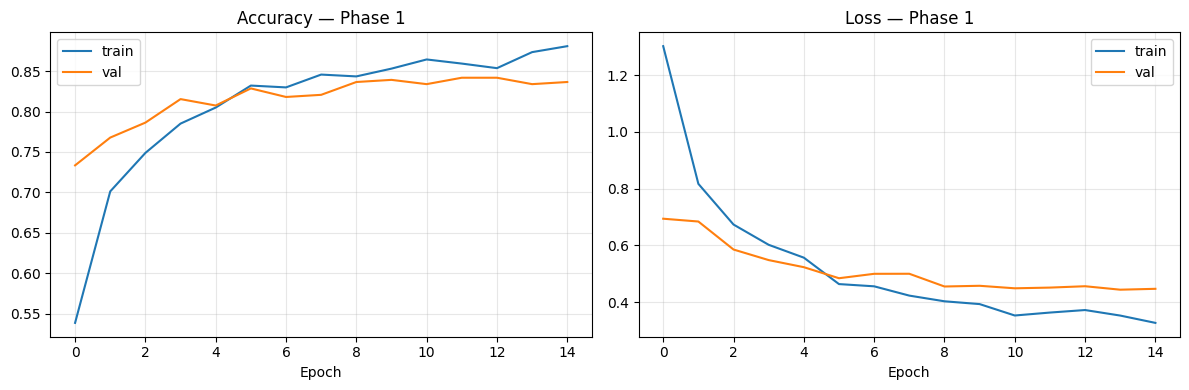

In [14]:
# Courbes d'entraînement Phase 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_phase1.history['accuracy'], label='train')
axes[0].plot(history_phase1.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy — Phase 1')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_phase1.history['loss'], label='train')
axes[1].plot(history_phase1.history['val_loss'], label='val')
axes[1].set_title('Loss — Phase 1')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Étape 12 — Phase 2 : Fine-tuning
L'idée : on dégèle les 30 dernières couches de MobileNetV2 et on réentraîne avec un LR très petit pour ajuster finement les features au domaine "déchets".

In [15]:
# ============================================================
# PHASE 2 : FINE-TUNING des dernières couches de MobileNetV2
# ============================================================

# Dégeler la base entière, puis re-geler les couches profondes
base_model.trainable = True

# On garde figées toutes les couches sauf les 30 dernières
# Ces couches basses détectent des motifs très généraux (bords, textures)
# On veut juste affiner les couches hautes (plus spécifiques)
FINE_TUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Compter les paramètres entraînables maintenant
trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Couches dégelées : {30} dernières / {len(base_model.layers)} au total")
print(f"Paramètres entraînables maintenant : {trainable_count:,}")

# Recompiler avec un learning rate BEAUCOUP plus petit
# Sinon on va exploser les poids pré-entraînés de MobileNetV2
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 100× plus petit que Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Couches dégelées : 30 dernières / 154 au total
Paramètres entraînables maintenant : 1,691,142


In [16]:
callbacks_phase2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("=" * 60)
print("PHASE 2 : Fine-tuning des dernières couches de MobileNetV2")
print("=" * 60)

history_phase2 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_phase2,
    verbose=1
)

PHASE 2 : Fine-tuning des dernières couches de MobileNetV2
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 61s 734ms/step - accuracy: 0.7381 - loss: 0.7194 - val_accuracy: 0.8338 - val_loss: 0.4393 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 477ms/step - accuracy: 0.7890 - loss: 0.5733 - val_accuracy: 0.8364 - val_loss: 0.4398 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 470ms/step - accuracy: 0.8133 - loss: 0.5349 - val_accuracy: 0.8391 - val_loss: 0.4389 - learning_rate: 1.0000e-05
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 465ms/step - accuracy: 0.8184 - loss: 0.5026 - val_accuracy: 0.8417 - val_loss: 0.4337 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 460ms/step - accuracy: 0.8247 - loss: 0.4684 - val_accuracy: 0.8470 - val_loss: 0.4287 - learning_rate: 1.0000e-05
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 455ms/step - accuracy: 0.8343 - loss: 0.4432 - val_accuracy: 0.8391 - val_loss: 0.4241 - learning_rate: 1.0000e-05

# Étape 12.5 — Visualiser Phase 2

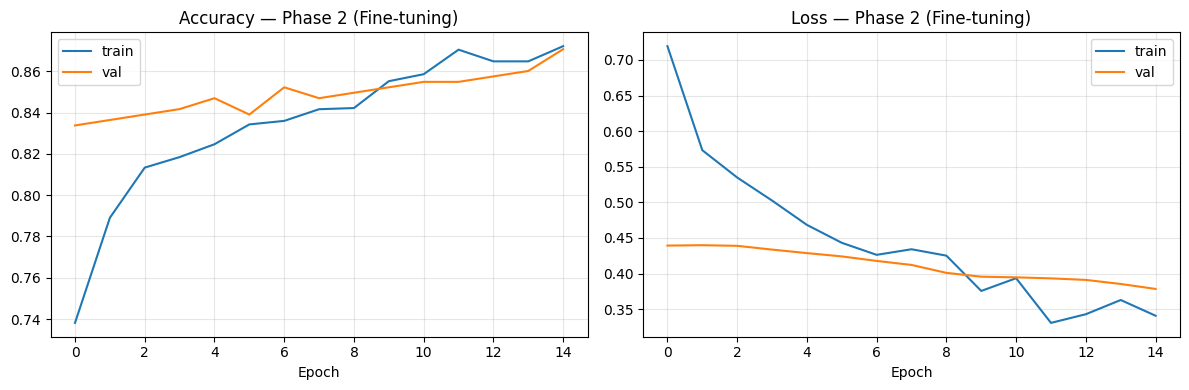

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_phase2.history['accuracy'], label='train')
axes[0].plot(history_phase2.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy — Phase 2 (Fine-tuning)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_phase2.history['loss'], label='train')
axes[1].plot(history_phase2.history['val_loss'], label='val')
axes[1].set_title('Loss — Phase 2 (Fine-tuning)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Étape 13 — Évaluation sur le TEST set

In [18]:
# ============================================================
# ÉVALUATION SUR TEST SET
# ============================================================
print("Évaluation sur le test set...")
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\n{'='*60}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"{'='*60}")

Évaluation sur le test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8553 - loss: 0.3923

Test Accuracy : 85.53%
Test Loss     : 0.3923


12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 526ms/step

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   cardboard      0.940     0.783     0.855        60
       glass      0.861     0.816     0.838        76
       metal      0.814     0.919     0.864        62
       paper      0.909     0.899     0.904        89
     plastic      0.831     0.877     0.853        73
       trash      0.652     0.750     0.698        20

    accuracy                          0.855       380
   macro avg      0.835     0.841     0.835       380
weighted avg      0.860     0.855     0.856       380



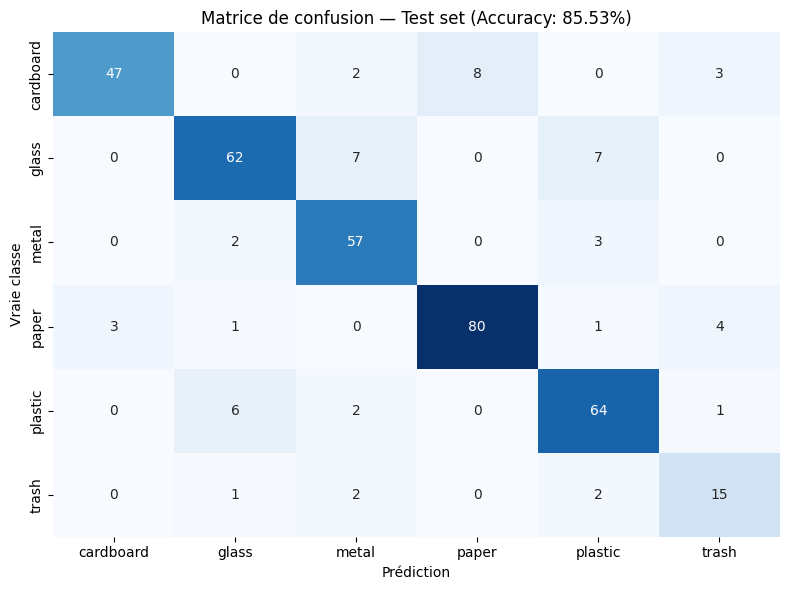

In [19]:
# ============================================================
# PRÉDICTIONS + MATRICE DE CONFUSION + RAPPORT DÉTAILLÉ
# ============================================================

# Reset le generator (par sécurité) et prédire
test_gen.reset()
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes

# Noms des classes dans l'ordre des indices
class_names_ordered = list(train_gen.class_indices.keys())

# Rapport de classification
print("\n" + "="*60)
print("RAPPORT DE CLASSIFICATION")
print("="*60)
print(classification_report(
    y_true, y_pred,
    target_names=class_names_ordered,
    digits=3
))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_ordered,
    yticklabels=class_names_ordered,
    cbar=False
)
plt.xlabel('Prédiction')
plt.ylabel('Vraie classe')
plt.title(f'Matrice de confusion — Test set (Accuracy: {test_acc*100:.2f}%)')
plt.tight_layout()
plt.show()

# Étape 14 — Sauvegarder le modèle

In [20]:
# ============================================================
# SAUVEGARDE DU MODÈLE
# ============================================================
MODEL_PATH = '/content/modele_eco_sort.keras'
model.save(MODEL_PATH)

# Vérifier la taille
import os
size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Modèle sauvegardé : {MODEL_PATH}")
print(f"Taille : {size_mb:.2f} MB")

Modèle sauvegardé : /content/modele_eco_sort.keras
Taille : 22.73 MB


# Étape 15 — Test d'inférence de sanity check

Modèle rechargé ✅


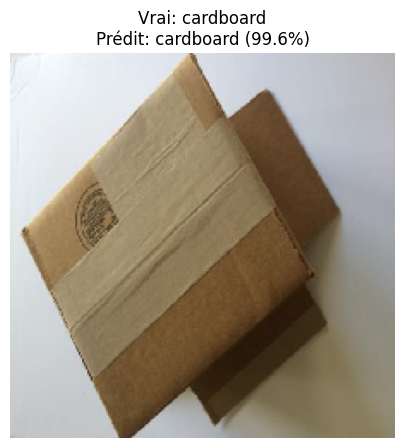


Toutes les probabilités :
  cardboard    : 99.57%
  glass        :  0.00%
  metal        :  0.00%
  paper        :  0.43%
  plastic      :  0.00%
  trash        :  0.00%


In [21]:
# ============================================================
# TEST DE RECHARGEMENT + INFÉRENCE
# ============================================================
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image

# Recharger le modèle depuis le disque
loaded_model = load_model(MODEL_PATH)
print("Modèle rechargé ✅")

# Prendre une image du test set au hasard
sample_row = test_df.sample(1, random_state=1).iloc[0]
img_path = sample_row['path']
true_label = sample_row['label']

# Prétraiter l'image
img = keras_image.load_img(img_path, target_size=IMG_SIZE)
img_array = keras_image.img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Prédire
probas = loaded_model.predict(img_array, verbose=0)[0]
predicted_idx = np.argmax(probas)
predicted_label = class_names_ordered[predicted_idx]
confidence = probas[predicted_idx] * 100

# Afficher
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(
    f"Vrai: {true_label}\n"
    f"Prédit: {predicted_label} ({confidence:.1f}%)",
    fontsize=12
)
plt.axis('off')
plt.show()

# Toutes les probabilités
print("\nToutes les probabilités :")
for name, proba in zip(class_names_ordered, probas):
    print(f"  {name:12s} : {proba*100:5.2f}%")

# Étape 16 — Télécharger le modèle en local

In [22]:
from google.colab import files
files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>